# Text Classification for Topic Modeling

# NLP Project | DLBAIPNLP01

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

print("All imports successful!")

All imports successful!


## Download NLTK Data

In [2]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK data ready!")

NLTK data ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\diksh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\diksh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Load the Dataset

In [3]:
from sklearn.datasets import fetch_20newsgroups

# Load training and test sets
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

print(f"Training documents: {len(train_data.data)}")
print(f"Test documents:     {len(test_data.data)}")
print(f"Number of topics:   {len(train_data.target_names)}")

Training documents: 11314
Test documents:     7532
Number of topics:   20


## Explore Categories

In [4]:
print("All 20 categories:\n")
for i, name in enumerate(train_data.target_names):
    print(f"  {i:2d}. {name}")

All 20 categories:

   0. alt.atheism
   1. comp.graphics
   2. comp.os.ms-windows.misc
   3. comp.sys.ibm.pc.hardware
   4. comp.sys.mac.hardware
   5. comp.windows.x
   6. misc.forsale
   7. rec.autos
   8. rec.motorcycles
   9. rec.sport.baseball
  10. rec.sport.hockey
  11. sci.crypt
  12. sci.electronics
  13. sci.med
  14. sci.space
  15. soc.religion.christian
  16. talk.politics.guns
  17. talk.politics.mideast
  18. talk.politics.misc
  19. talk.religion.misc


## Inspect a Sample Document

In [5]:
# Look at the first document and its label
sample_index = 0
print(f"Category: {train_data.target_names[train_data.target[sample_index]]}")
print(f"\nDocument text:\n{'-'*50}")
print(train_data.data[sample_index][:500])

Category: rec.autos

Document text:
--------------------------------------------------
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


## Visualize Category Distribution

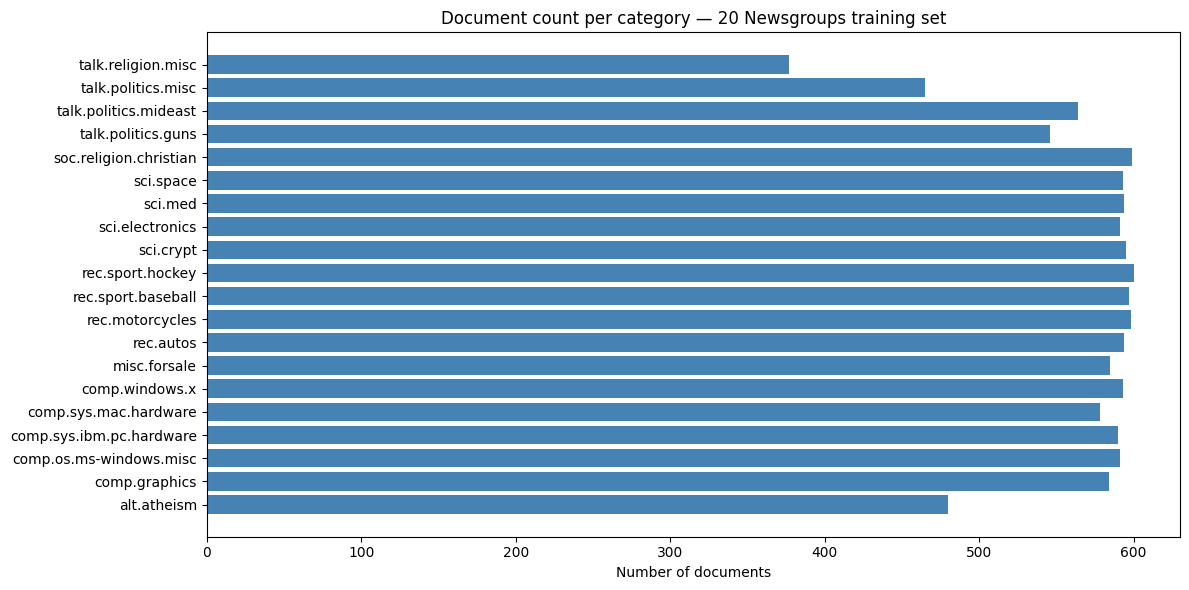

Chart saved!


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Count documents per category
categories = train_data.target_names
counts = [sum(train_data.target == i) for i in range(len(categories))]

plt.figure(figsize=(12, 6))
bars = plt.barh(categories, counts, color='steelblue')
plt.xlabel('Number of documents')
plt.title('Document count per category — 20 Newsgroups training set')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

## Define Preprocessing Function

In [7]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove numbers and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("Preprocessing function ready!")

Preprocessing function ready!


## Apply Preprocessing

In [8]:
print("Preprocessing training data...")
train_clean = [preprocess(doc) for doc in train_data.data]

print("Preprocessing test data...")
test_clean = [preprocess(doc) for doc in test_data.data]

print(f"\nDone! {len(train_clean)} training and {len(test_clean)} test documents processed.")

Preprocessing training data...
Preprocessing test data...

Done! 11314 training and 7532 test documents processed.


## Before vs After Preprocessing

In [9]:
sample = 0
print("BEFORE preprocessing:")
print("-" * 50)
print(train_data.data[sample][:300])

print("\nAFTER preprocessing:")
print("-" * 50)
print(train_clean[sample][:300])

BEFORE preprocessing:
--------------------------------------------------
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I k

AFTER preprocessing:
--------------------------------------------------
wondering anyone could enlighten car saw day door sport car looked late early called bricklin door really small addition front bumper separate rest body know anyone tellme model name engine spec year production car made history whatever info funky looking car please email


## TF-IDF Feature Extraction

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)

X_train = vectorizer.fit_transform(train_clean)
X_test  = vectorizer.transform(test_clean)

y_train = train_data.target
y_test  = test_data.target

print(f"Training matrix shape: {X_train.shape}")
print(f"Test matrix shape:     {X_test.shape}")
print("\nText successfully converted to numbers!")

Training matrix shape: (11314, 10000)
Test matrix shape:     (7532, 10000)

Text successfully converted to numbers!


## Compare CountVectorizer vs TF-IDF

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Compare raw term-frequency (CountVectorizer) vs TF-IDF weighting
count_vec     = CountVectorizer(max_features=10000)
X_train_count = count_vec.fit_transform(train_clean)
X_test_count  = count_vec.transform(test_clean)

nb_count_acc = accuracy_score(y_test, MultinomialNB().fit(X_train_count, y_train).predict(X_test_count))
nb_tfidf_acc = accuracy_score(y_test, MultinomialNB().fit(X_train,       y_train).predict(X_test))

print("Vectorizer Comparison — Naive Bayes, 10,000 features")
print("=" * 50)
print(f"  CountVectorizer (term frequency) : {nb_count_acc*100:.2f}%")
print(f"  TF-IDF                           : {nb_tfidf_acc*100:.2f}%")
winner = 'TF-IDF' if nb_tfidf_acc >= nb_count_acc else 'CountVectorizer'
diff   = abs(nb_tfidf_acc - nb_count_acc) * 100
print(f"\nWinner: {winner} (+{diff:.2f}%). TF-IDF continues as the main vectorizer.")

Vectorizer Comparison — Naive Bayes, 10,000 features
  CountVectorizer (term frequency) : 64.35%
  TF-IDF                           : 66.08%

Winner: TF-IDF (+1.73%). TF-IDF continues as the main vectorizer.


## Visualize Top TF-IDF Words

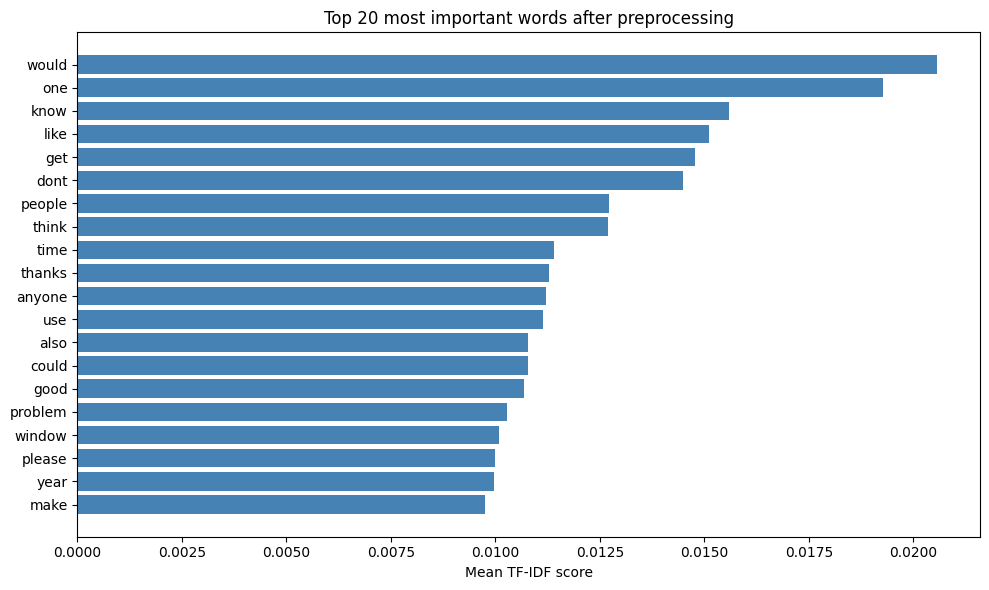

Chart saved!


In [12]:
import matplotlib.pyplot as plt

# Get top 20 words by TF-IDF score
feature_names = vectorizer.get_feature_names_out()
mean_scores = X_train.mean(axis=0).A1
top_indices = mean_scores.argsort()[-20:][::-1]
top_words = [feature_names[i] for i in top_indices]
top_scores = [mean_scores[i] for i in top_indices]

plt.figure(figsize=(10, 6))
plt.barh(top_words[::-1], top_scores[::-1], color='steelblue')
plt.xlabel('Mean TF-IDF score')
plt.title('Top 20 most important words after preprocessing')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()
print("Chart saved!")

## Train Naive Bayes Classifier

In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Train the model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict
nb_predictions = nb_model.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

Naive Bayes Accuracy: 0.6608 (66.08%)


## Train SVM Classifier

In [14]:
from sklearn.svm import LinearSVC

# Train the model
svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train, y_train)

# Predict
svm_predictions = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

SVM Accuracy: 0.6498 (64.98%)


## Train Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

# 5-Fold Cross-Validation (may take ~2 minutes)
print("\n5-Fold Cross-Validation on Full Training Data:")
print("=" * 55)
nb_cv  = cross_val_score(MultinomialNB(), X_train, y_train, cv=5, scoring='accuracy')
svm_cv = cross_val_score(LinearSVC(max_iter=2000), X_train, y_train, cv=5, scoring='accuracy')
lr_cv  = cross_val_score(LogisticRegression(max_iter=1000, C=1.0), X_train, y_train, cv=5, scoring='accuracy')
print(f"Naive Bayes          — Mean: {nb_cv.mean()*100:.2f}%  Std: ±{nb_cv.std()*100:.2f}%")
print(f"SVM                  — Mean: {svm_cv.mean()*100:.2f}%  Std: ±{svm_cv.std()*100:.2f}%")
print(f"Logistic Regression  — Mean: {lr_cv.mean()*100:.2f}%  Std: ±{lr_cv.std()*100:.2f}%")

Logistic Regression Accuracy: 0.6665 (66.65%)

5-Fold Cross-Validation on Full Training Data:
Naive Bayes          — Mean: 70.34%  Std: ±0.57%
SVM                  — Mean: 71.96%  Std: ±0.78%
Logistic Regression  — Mean: 71.42%  Std: ±0.46%


## Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

print("Hyperparameter Tuning — GridSearchCV (5-fold CV)")
print("=" * 55)

# Tune Naive Bayes smoothing parameter alpha
nb_grid = GridSearchCV(MultinomialNB(),
                       {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]},
                       cv=5, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train, y_train)
nb_tuned_acc = accuracy_score(y_test, nb_grid.best_estimator_.predict(X_test))
print(f"NB  best alpha = {nb_grid.best_params_['alpha']:<5} "
      f"→ test: {nb_tuned_acc*100:.2f}%  (baseline: {nb_accuracy*100:.2f}%)")

# Tune Logistic Regression regularisation strength C
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000),
                       {'C': [0.1, 1.0, 5.0, 10.0]},
                       cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
lr_tuned_acc = accuracy_score(y_test, lr_grid.best_estimator_.predict(X_test))
print(f"LR  best C     = {lr_grid.best_params_['C']:<5} "
      f"→ test: {lr_tuned_acc*100:.2f}%  (baseline: {lr_accuracy*100:.2f}%)")

print("\nNote: tuned models are used for reporting only; "
      "main pipeline variables are unchanged.")

Hyperparameter Tuning — GridSearchCV (5-fold CV)
NB  best alpha = 0.1   → test: 67.63%  (baseline: 66.08%)
LR  best C     = 5.0   → test: 65.96%  (baseline: 66.65%)

Note: tuned models are used for reporting only; main pipeline variables are unchanged.


## Compare All Three Models

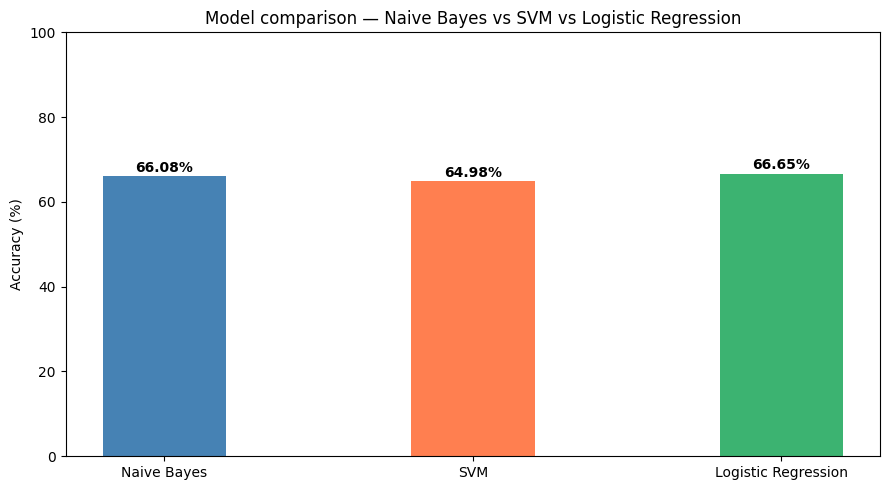

In [17]:
models = ['Naive Bayes', 'SVM', 'Logistic Regression']
accuracies = [nb_accuracy, svm_accuracy, lr_accuracy]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, [a*100 for a in accuracies],
               color=['steelblue', 'coral', 'mediumseagreen'], width=0.4)
plt.ylabel('Accuracy (%)')
plt.title('Model comparison — Naive Bayes vs SVM vs Logistic Regression')
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc*100:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Detailed Classification Report

In [18]:
from sklearn.metrics import classification_report

# Dynamically select the best-performing model
candidates = [
    ('Naive Bayes',        nb_accuracy,  nb_predictions,  nb_model),
    ('SVM',                svm_accuracy, svm_predictions, svm_model),
    ('Logistic Regression',lr_accuracy,  lr_predictions,  lr_model),
]
best_model_name, best_model_acc, best_predictions, best_model_obj = max(candidates, key=lambda x: x[1])

print(f"Detailed Classification Report — {best_model_name} (Accuracy: {best_model_acc*100:.2f}%)")
print("=" * 60)
print(classification_report(y_test, best_predictions,
                            target_names=test_data.target_names))

Detailed Classification Report — Logistic Regression (Accuracy: 66.65%)
                          precision    recall  f1-score   support

             alt.atheism       0.49      0.48      0.49       319
           comp.graphics       0.60      0.66      0.63       389
 comp.os.ms-windows.misc       0.62      0.56      0.59       394
comp.sys.ibm.pc.hardware       0.65      0.60      0.63       392
   comp.sys.mac.hardware       0.70      0.66      0.68       385
          comp.windows.x       0.72      0.68      0.70       395
            misc.forsale       0.75      0.78      0.77       390
               rec.autos       0.75      0.66      0.70       396
         rec.motorcycles       0.49      0.80      0.60       398
      rec.sport.baseball       0.80      0.78      0.79       397
        rec.sport.hockey       0.89      0.87      0.88       399
               sci.crypt       0.85      0.66      0.74       396
         sci.electronics       0.53      0.57      0.55       393
   

## Confusion Matrix

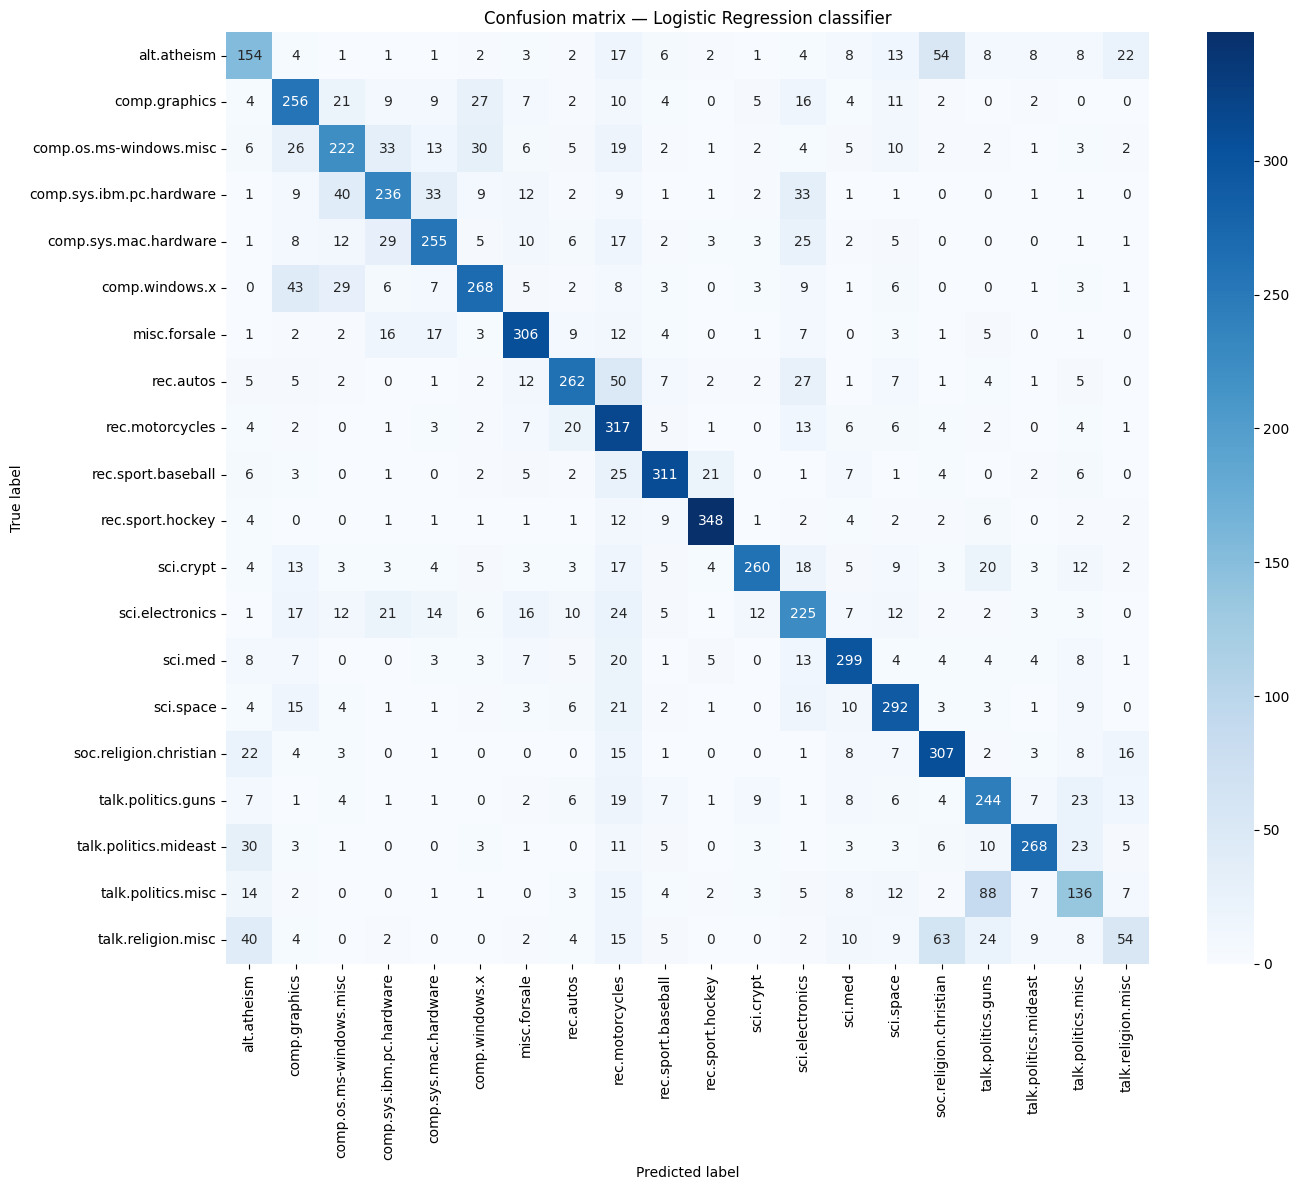

Confusion matrix saved!


In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.target_names,
            yticklabels=test_data.target_names)
plt.title(f'Confusion matrix — {best_model_name} classifier')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

## Most Confused Category Pairs

In [20]:
import numpy as np

# Identify the most frequently confused category pairs
cm_err = confusion_matrix(y_test, best_predictions).copy()
np.fill_diagonal(cm_err, 0)  # zero correct predictions to expose errors

confused = [
    (cm_err[i, j], test_data.target_names[i], test_data.target_names[j])
    for i in range(len(test_data.target_names))
    for j in range(len(test_data.target_names))
    if i != j and cm_err[i, j] > 0
]
confused.sort(reverse=True)

print(f"Top 10 Most Confused Category Pairs — {best_model_name}")
print("=" * 68)
print(f"{'True Category':<32} {'Predicted As':<28} {'Count':>5}")
print("-" * 68)
for count, true_cat, pred_cat in confused[:10]:
    print(f"{true_cat:<32} {pred_cat:<28} {count:>5}")

print("\nInsight: categories sharing vocabulary (religion/politics, "
      "comp sub-groups) are hardest to separate.")

Top 10 Most Confused Category Pairs — Logistic Regression
True Category                    Predicted As                 Count
--------------------------------------------------------------------
talk.politics.misc               talk.politics.guns              88
talk.religion.misc               soc.religion.christian          63
alt.atheism                      soc.religion.christian          54
rec.autos                        rec.motorcycles                 50
comp.windows.x                   comp.graphics                   43
talk.religion.misc               alt.atheism                     40
comp.sys.ibm.pc.hardware         comp.os.ms-windows.misc         40
comp.sys.ibm.pc.hardware         sci.electronics                 33
comp.sys.ibm.pc.hardware         comp.sys.mac.hardware           33
comp.os.ms-windows.misc          comp.sys.ibm.pc.hardware        33

Insight: categories sharing vocabulary (religion/politics, comp sub-groups) are hardest to separate.


## Predict a Custom Text

In [21]:
# Write any text and see what topic the model predicts
my_text = ["The new graphics card offers incredible performance for gaming and 3D rendering"]

my_text_clean  = [preprocess(my_text[0])]
my_text_vector = vectorizer.transform(my_text_clean)

prediction = best_model_obj.predict(my_text_vector)
print(f"Input text:      {my_text[0]}")
print(f"Predicted topic: {test_data.target_names[prediction[0]]}")

Input text:      The new graphics card offers incredible performance for gaming and 3D rendering
Predicted topic: misc.forsale


## Multi-type Text Demonstration

In [22]:
# Demonstrate classifier across diverse text types
# (addresses task requirement: handle news, academic, and social media text)
test_examples = [
    ("News article",   "NASA's new telescope captured images showing evidence of black holes in a distant galaxy"),
    ("Social media",   "omg last nights hockey game was insane!! best match of the season #hockey #nhl"),
    ("Academic paper", "This paper presents a novel encryption scheme resistant to quantum computing attacks"),
    ("Classified ad",  "For sale: barely used laptop, excellent condition, asking 300 dollars, serious buyers only"),
    ("Medical text",   "The patient presented with symptoms of chronic fatigue and elevated cortisol levels"),
]

print(f"Multi-text-type demo — {best_model_name}")
print("=" * 70)
for text_type, text in test_examples:
    vec  = vectorizer.transform([preprocess(text)])
    pred = best_model_obj.predict(vec)[0]
    print(f"[{text_type:<15}] → {test_data.target_names[pred]}")
    print(f"  \"{text[:72]}\"")
    print()

Multi-text-type demo — Logistic Regression
[News article   ] → sci.space
  "NASA's new telescope captured images showing evidence of black holes in "

[Social media   ] → rec.sport.hockey
  "omg last nights hockey game was insane!! best match of the season #hocke"

[Academic paper ] → sci.crypt
  "This paper presents a novel encryption scheme resistant to quantum compu"

[Classified ad  ] → misc.forsale
  "For sale: barely used laptop, excellent condition, asking 300 dollars, s"

[Medical text   ] → sci.med
  "The patient presented with symptoms of chronic fatigue and elevated cort"



## Small vs Full Dataset Comparison

In [23]:
from sklearn.datasets import fetch_20newsgroups

# Small dataset (4 categories only)
categories_small = ['rec.sport.hockey', 'sci.space', 'comp.graphics', 'talk.politics.guns']

train_small = fetch_20newsgroups(subset='train', categories=categories_small,
                                  remove=('headers', 'footers', 'quotes'))
test_small  = fetch_20newsgroups(subset='test',  categories=categories_small,
                                  remove=('headers', 'footers', 'quotes'))

# Preprocess
train_small_clean = [preprocess(doc) for doc in train_small.data]
test_small_clean  = [preprocess(doc) for doc in test_small.data]

# Vectorize
vec_small = TfidfVectorizer(max_features=5000)
X_train_small = vec_small.fit_transform(train_small_clean)
X_test_small  = vec_small.transform(test_small_clean)

# Train and evaluate all three models
nb_small = MultinomialNB()
nb_small.fit(X_train_small, train_small.target)
nb_small_acc = accuracy_score(test_small.target, nb_small.predict(X_test_small))

svm_small = LinearSVC(max_iter=2000)
svm_small.fit(X_train_small, train_small.target)
svm_small_acc = accuracy_score(test_small.target, svm_small.predict(X_test_small))

lr_small = LogisticRegression(max_iter=1000, C=1.0)
lr_small.fit(X_train_small, train_small.target)
lr_small_acc = accuracy_score(test_small.target, lr_small.predict(X_test_small))

print(f"Small dataset (4 categories):")
print(f"  Naive Bayes accuracy:         {nb_small_acc*100:.2f}%")
print(f"  SVM accuracy:                 {svm_small_acc*100:.2f}%")
print(f"  Logistic Regression accuracy: {lr_small_acc*100:.2f}%")
print(f"\nFull dataset (20 categories):")
print(f"  Naive Bayes accuracy:         {nb_accuracy*100:.2f}%")
print(f"  SVM accuracy:                 {svm_accuracy*100:.2f}%")
print(f"  Logistic Regression accuracy: {lr_accuracy*100:.2f}%")

Small dataset (4 categories):
  Naive Bayes accuracy:         88.94%
  SVM accuracy:                 87.26%
  Logistic Regression accuracy: 88.23%

Full dataset (20 categories):
  Naive Bayes accuracy:         66.08%
  SVM accuracy:                 64.98%
  Logistic Regression accuracy: 66.65%


## Visualize Small vs Full Performance

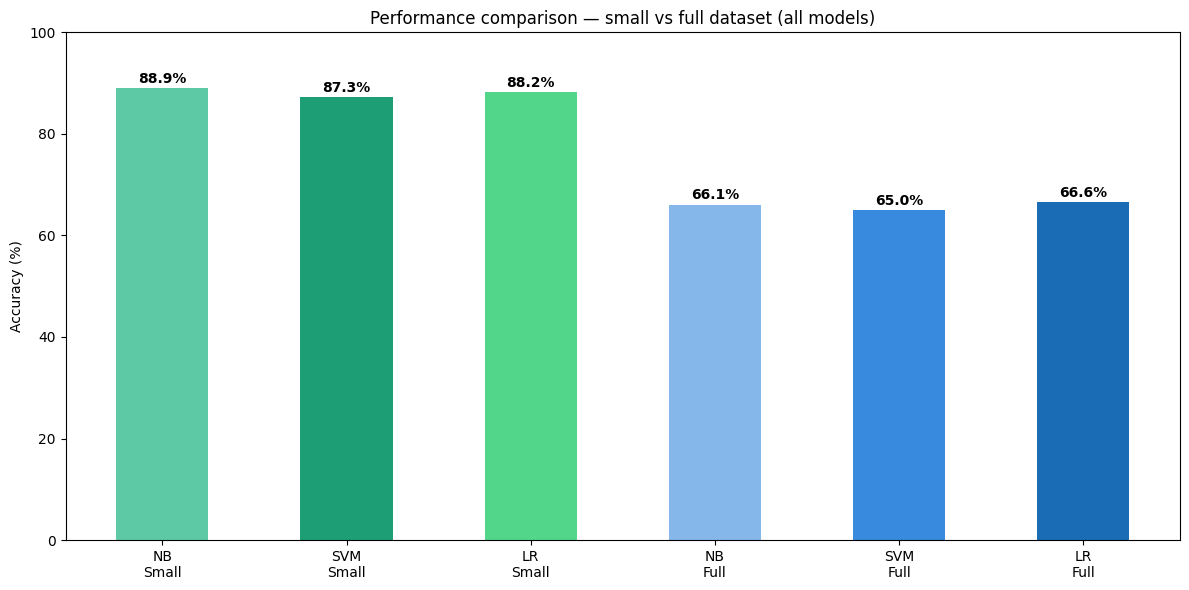

Comparison chart saved!


In [24]:
labels = ['NB\nSmall', 'SVM\nSmall', 'LR\nSmall',
          'NB\nFull', 'SVM\nFull', 'LR\nFull']
values = [nb_small_acc*100, svm_small_acc*100, lr_small_acc*100,
          nb_accuracy*100,  svm_accuracy*100,  lr_accuracy*100]
colors = ['#5DCAA5', '#1D9E75', '#52D68A', '#85B7EB', '#378ADD', '#1A6DB5']

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, values, color=colors, width=0.5)
plt.ylabel('Accuracy (%)')
plt.title('Performance comparison — small vs full dataset (all models)')
plt.ylim(0, 100)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('small_vs_full_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved!")

## F1 Score Per Category

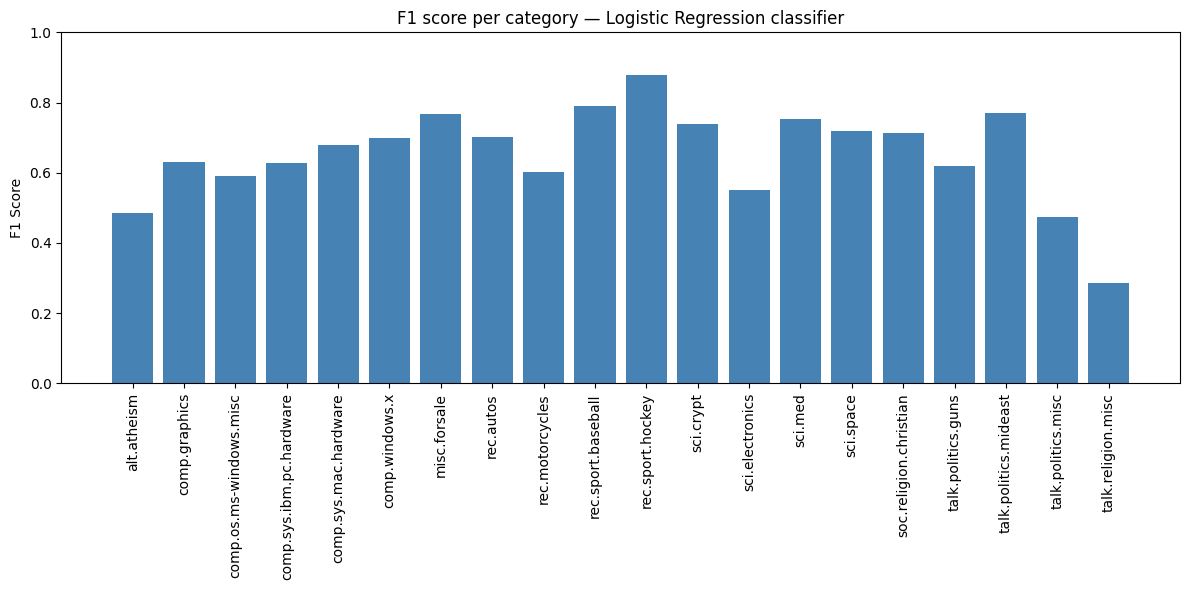

Best category:  rec.sport.hockey  (F1 = 0.879)
Worst category: talk.religion.misc (F1 = 0.286)


In [25]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, best_predictions, average=None
)

# Plot F1 score per category
plt.figure(figsize=(12, 6))
x = range(len(test_data.target_names))
plt.bar(x, f1, color='steelblue')
plt.xticks(x, test_data.target_names, rotation=90)
plt.ylabel('F1 Score')
plt.title(f'F1 score per category — {best_model_name} classifier')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('f1_per_category.png', dpi=150)
plt.show()

# Print best and worst categories
best_cat  = test_data.target_names[f1.argmax()]
worst_cat = test_data.target_names[f1.argmin()]
print(f"Best category:  {best_cat}  (F1 = {f1.max():.3f})")
print(f"Worst category: {worst_cat} (F1 = {f1.min():.3f})")

## Top Discriminative Words Per Category

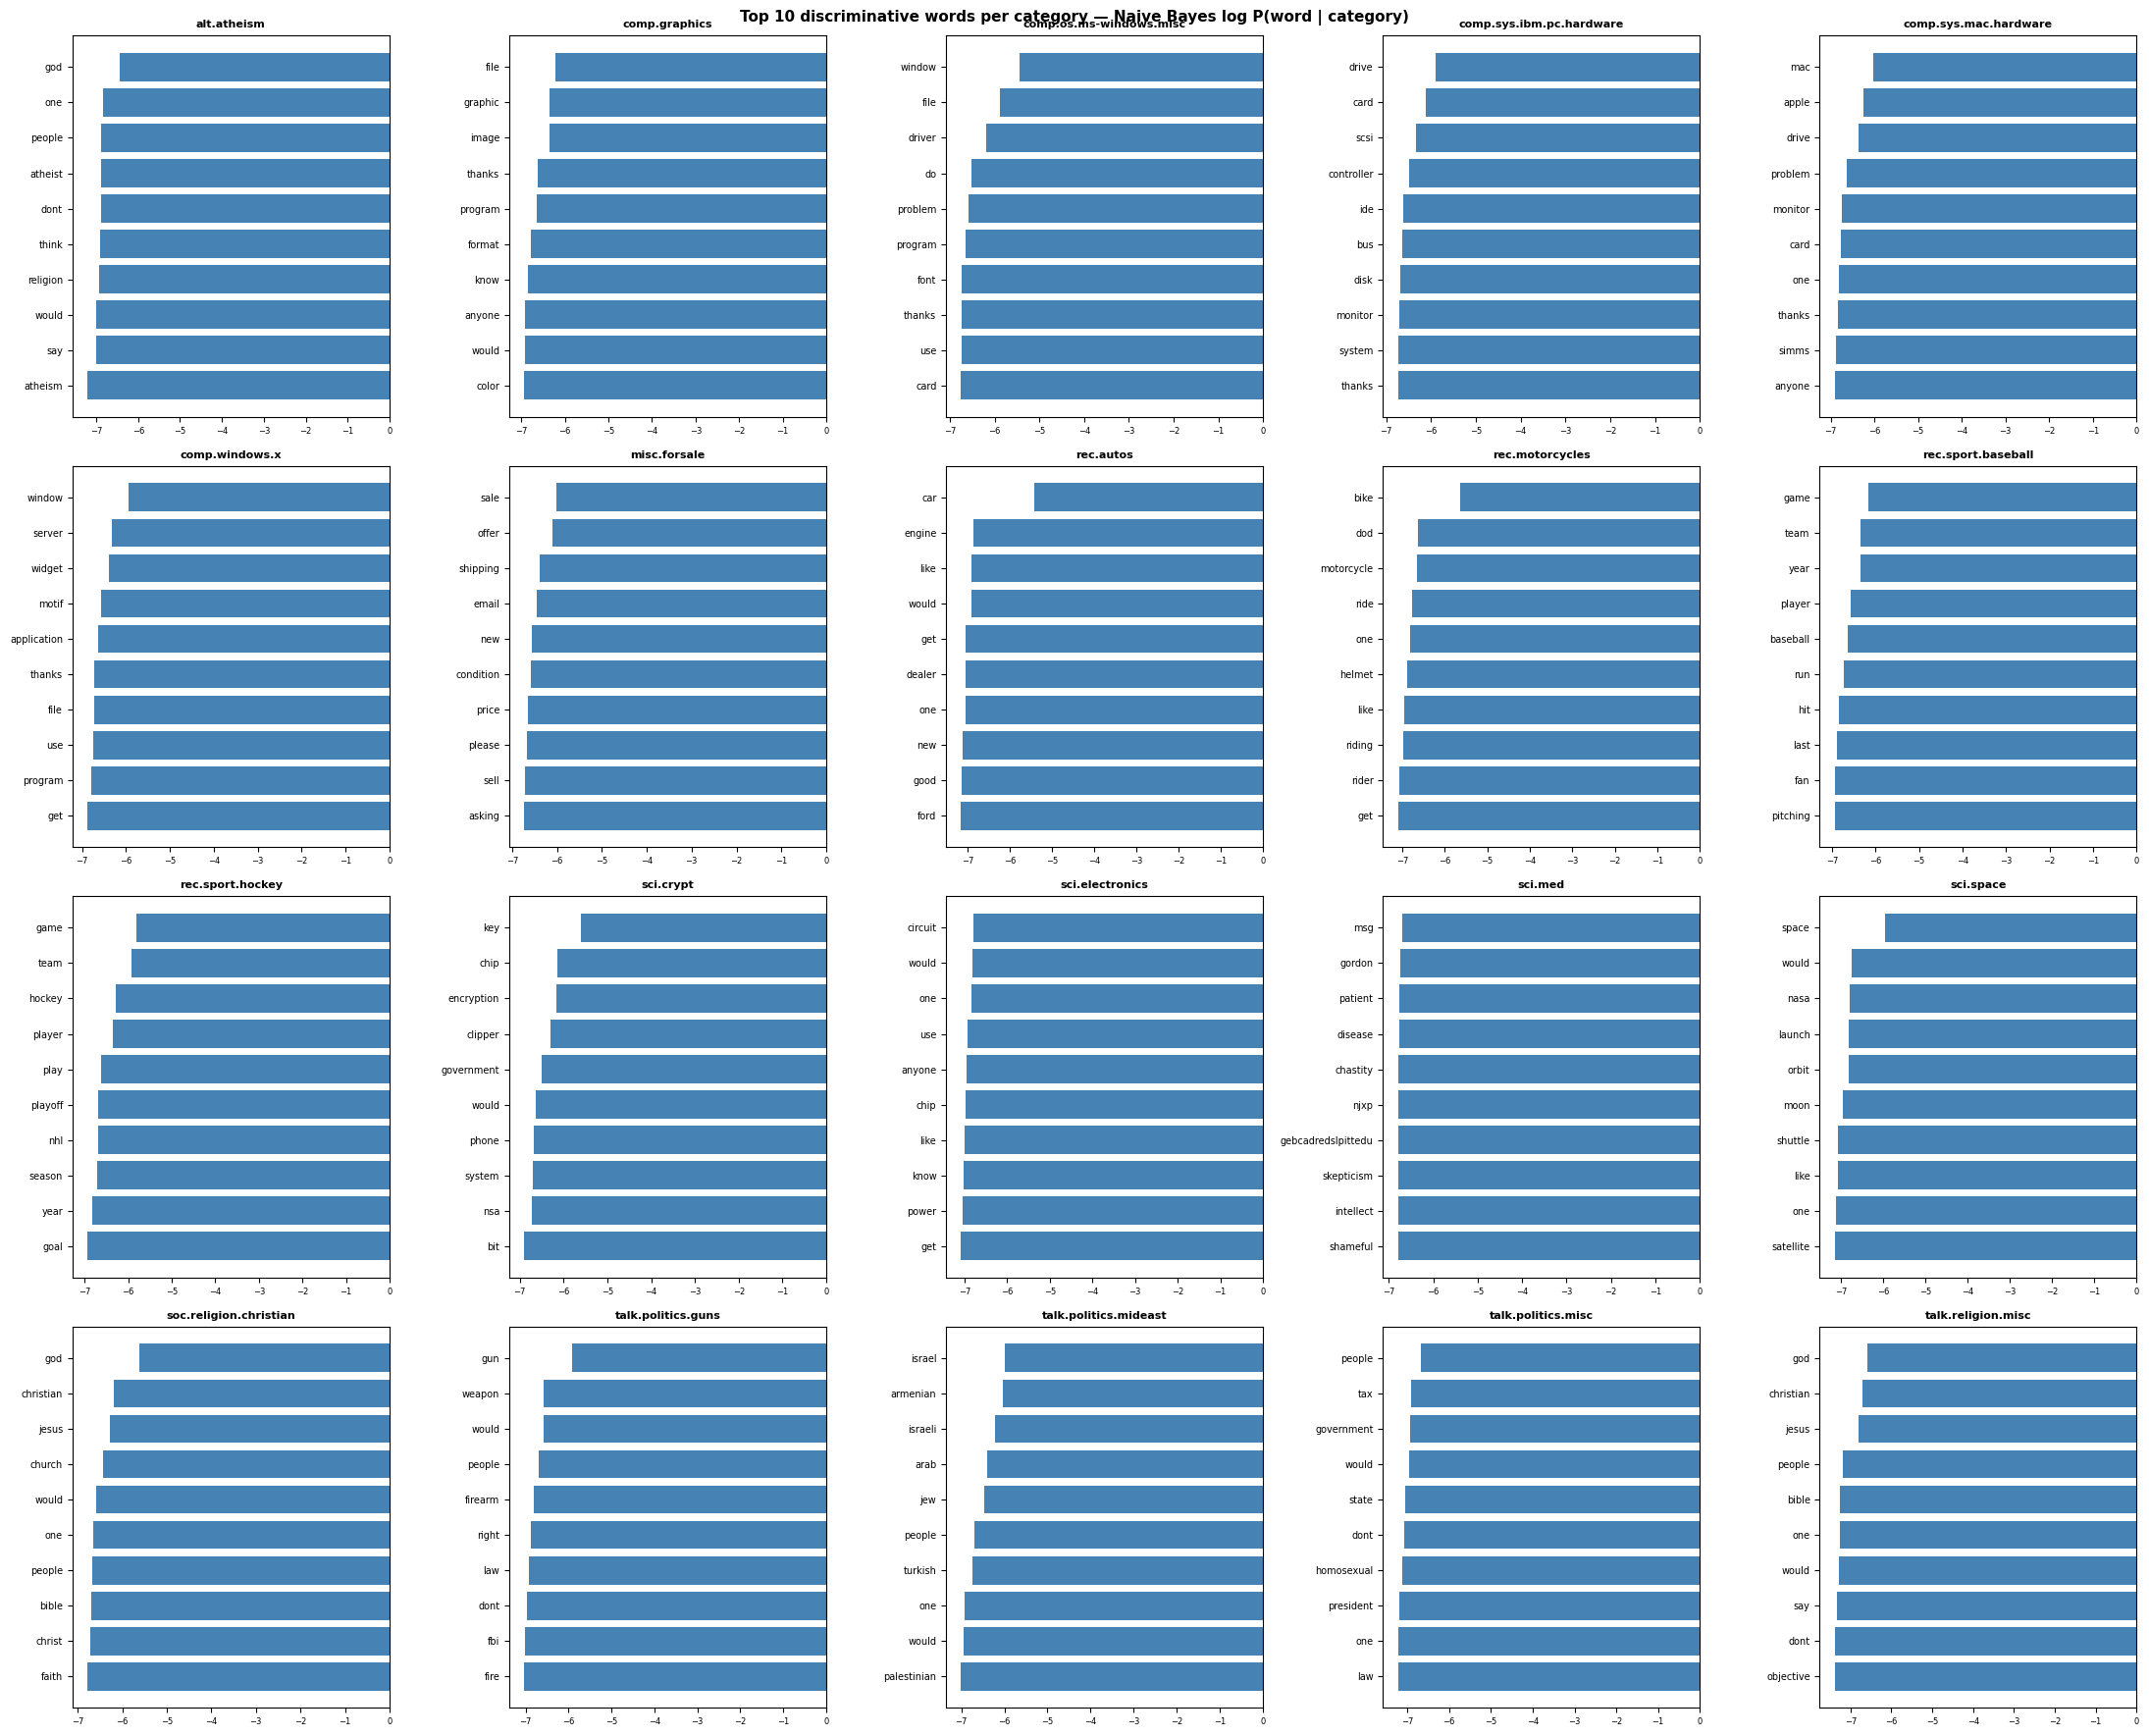

Chart saved!


In [26]:
# Top 10 most discriminative words per category using Naive Bayes log P(word | category)
feature_names_nb = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(4, 5, figsize=(22, 18))
axes = axes.flatten()

for i, category in enumerate(test_data.target_names):
    log_probs = nb_model.feature_log_prob_[i]
    top_idx   = log_probs.argsort()[-10:][::-1]
    top_words = [feature_names_nb[j] for j in top_idx]
    top_vals  = [log_probs[j]         for j in top_idx]

    axes[i].barh(top_words[::-1], top_vals[::-1], color='steelblue')
    axes[i].set_title(category, fontsize=8, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].tick_params(axis='x', labelsize=6)

plt.suptitle('Top 10 discriminative words per category — Naive Bayes log P(word | category)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Final Results Summary Table

In [27]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM', 'Logistic Regression',
              'Naive Bayes', 'SVM', 'Logistic Regression'],
    'Dataset': ['Small (4 topics)', 'Small (4 topics)', 'Small (4 topics)',
                'Full (20 topics)', 'Full (20 topics)', 'Full (20 topics)'],
    'Accuracy (%)': [round(nb_small_acc*100, 2),
                     round(svm_small_acc*100, 2),
                     round(lr_small_acc*100, 2),
                     round(nb_accuracy*100, 2),
                     round(svm_accuracy*100, 2),
                     round(lr_accuracy*100, 2)]
})

print("=" * 58)
print("FINAL RESULTS SUMMARY")
print("=" * 58)
print(results.to_string(index=False))
print("=" * 58)
print(f"\nBest overall model: {best_model_name} ({best_model_acc*100:.2f}% on full dataset)")

FINAL RESULTS SUMMARY
              Model          Dataset  Accuracy (%)
        Naive Bayes Small (4 topics)         88.94
                SVM Small (4 topics)         87.26
Logistic Regression Small (4 topics)         88.23
        Naive Bayes Full (20 topics)         66.08
                SVM Full (20 topics)         64.98
Logistic Regression Full (20 topics)         66.65

Best overall model: Logistic Regression (66.65% on full dataset)


## List All Saved Charts

In [28]:
import os

# List all saved charts
charts = [f for f in os.listdir('.') if f.endswith('.png')]
print("Charts saved for your report:")
for chart in charts:
    print(f"  {chart}")

print("\nAll results ready for the project report!")
print("\nNext step: push your notebook to GitHub")

Charts saved for your report:
  category_distribution.png
  confusion_matrix.png
  f1_per_category.png
  model_comparison.png
  small_vs_full_comparison.png
  top_words.png
  top_words_per_category.png

All results ready for the project report!

Next step: push your notebook to GitHub


## Save Trained Models

In [29]:
import joblib, os

os.makedirs('saved_models', exist_ok=True)
joblib.dump(nb_model,   'saved_models/naive_bayes.pkl')
joblib.dump(svm_model,  'saved_models/svm.pkl')
joblib.dump(lr_model,   'saved_models/logistic_regression.pkl')
joblib.dump(vectorizer, 'saved_models/tfidf_vectorizer.pkl')

print("All models and vectorizer saved to saved_models/")
print("\nTo reload and use in any script:")
print("  import joblib")
print("  model = joblib.load('saved_models/naive_bayes.pkl')")
print("  vec   = joblib.load('saved_models/tfidf_vectorizer.pkl')")

All models and vectorizer saved to saved_models/

To reload and use in any script:
  import joblib
  model = joblib.load('saved_models/naive_bayes.pkl')
  vec   = joblib.load('saved_models/tfidf_vectorizer.pkl')


## Final Results Output

In [30]:
print("=" * 58)
print("MY PROJECT RESULTS")
print("=" * 58)
print(f"Naive Bayes         - Small dataset: {nb_small_acc*100:.2f}%")
print(f"SVM                 - Small dataset: {svm_small_acc*100:.2f}%")
print(f"Logistic Regression - Small dataset: {lr_small_acc*100:.2f}%")
print()
print(f"Naive Bayes         - Full dataset:  {nb_accuracy*100:.2f}%")
print(f"SVM                 - Full dataset:  {svm_accuracy*100:.2f}%")
print(f"Logistic Regression - Full dataset:  {lr_accuracy*100:.2f}%")
print("=" * 58)

MY PROJECT RESULTS
Naive Bayes         - Small dataset: 88.94%
SVM                 - Small dataset: 87.26%
Logistic Regression - Small dataset: 88.23%

Naive Bayes         - Full dataset:  66.08%
SVM                 - Full dataset:  64.98%
Logistic Regression - Full dataset:  66.65%
